In [1]:
#Bike vs car dataset is in googledrive, so from colab I am accessing my drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files

#In order to import the datsets from kaggle the API token has been uploaded
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rasadulislam23f24079","key":"598b187f8ce7e779f629a7cc8579ae66"}'}

In [3]:
#In collab a kaggle folder is created
!mkdir -p ~/.kaggle
#Followed by copying the kaggel.json token into the folder
!cp kaggle.json ~/.kaggle/
#Providing a suitable permission for the token
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
# From kaggle the dataset is downloaded
!kaggle datasets download -d utkarshsaxenadn/car-vs-bike-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset
License(s): CC0-1.0
100% 103M/103M [00:01<00:00, 106MB/s]  



In [5]:
# unzip the dataset
!unzip car-vs-bike-classification-dataset.zip

Archive:  car-vs-bike-classification-dataset.zip
  inflating: Car-Bike-Dataset/Bike/Bike (1).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1).jpg  
  inflating: Car-Bike-Dataset/Bike/Bike (1).png  
  inflating: Car-Bike-Dataset/Bike/Bike (10).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (10).jpg  
  inflating: Car-Bike-Dataset/Bike/Bike (10).png  
  inflating: Car-Bike-Dataset/Bike/Bike (100).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (100).jpg  
  inflating: Car-Bike-Dataset/Bike/Bike (1000).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1001).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1002).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1003).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1004).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1005).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1006).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1007).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1008).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1009).jpeg  
 

In [6]:
import os
import shutil
import random

# Folder destination
original_dataset_dir = "/content/Car-Bike-Dataset"

# New folder for the split train/test dataset
base_dir = "/content/car_bike_split"

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

# Creating main folder for train/test
for folder in [train_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)


# Class definition
classes = ["Car", "Bike"]


# Creating class folders within main folders
for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

# ratio split
split_ratio = 0.8


# Splitting the dataset
for cls in classes:

    source_folder = os.path.join(original_dataset_dir, cls)

    images = os.listdir(source_folder)

    # Shuffling of images at random
    random.shuffle(images)

# 80% split
    split_index = int(len(images) * split_ratio)

# images are split into training and testing sets
    train_images = images[:split_index]
    test_images = images[split_index:]

    # Training copy
    for img in train_images:
        shutil.copy(
            os.path.join(source_folder, img),
            os.path.join(train_dir, cls, img)
        )

    # Testing copy
    for img in test_images:
        shutil.copy(
            os.path.join(source_folder, img),
            os.path.join(test_dir, cls, img)
        )

In [7]:
train_dir = "/content/car_bike_split/train"
test_dir = "/content/car_bike_split/test"

In [8]:
import os

print("Train Car:",
      len(os.listdir(os.path.join(train_dir, "Car"))))

print("Train Bike:",
      len(os.listdir(os.path.join(train_dir, "Bike"))))

print("Test Car:",
      len(os.listdir(os.path.join(test_dir, "Car"))))

print("Test Bike:",
      len(os.listdir(os.path.join(test_dir, "Bike"))))

Train Car: 1600
Train Bike: 1600
Test Car: 400
Test Bike: 400


In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Original dataset path
dataset_dir = "/content/Car-Bike-Dataset"

# ImageDataGenerator creation for the training data set
train_datagen = ImageDataGenerator(
    rescale=1./255, #normalisation
    validation_split=0.2  # Split 20% of the images for validation
)

# Training data loading and preparing
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',  # 'binary' for binary classification (bike vs car)
    subset='training'  # For the training set specify 'training'
)
# ImageDataGenerator creation for validation set
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Note: Using the same validation split as in the training set
)

# Validation data loading and preparation
validation_data = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary', # 'binary' for binary classification (bike vs car)
    subset='validation'  # For the validation set specify 'validation'
)

Found 2560 images belonging to 2 classes.
Found 640 images belonging to 2 classes.


In [10]:
#Importing necessary libaraies for CNN deep learning model
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,UpSampling2D, Dropout

In [11]:
# Creating custom CNN model

model = Sequential()

model.add(Conv2D(32, (3,3), padding='valid', activation='relu', input_shape=(256,256,3))) #32 filters
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64, (3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128, (3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu')) #Feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid')) #Output layer to conduct the binary classification

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
#binary_crossentropy - binary classification

In [13]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)
#fewer epochs are used since the dataset is small

Epoch 1/10
22/80 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.5138 - loss: 0.8427

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 172ms/step - accuracy: 0.7316 - loss: 0.5318 - val_accuracy: 0.8578 - val_loss: 0.3649
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.8887 - loss: 0.2618 - val_accuracy: 0.8719 - val_loss: 0.3459
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.9398 - loss: 0.1501 - val_accuracy: 0.8938 - val_loss: 0.2609
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - accuracy: 0.9711 - loss: 0.0816 - val_accuracy: 0.8906 - val_loss: 0.3131
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - accuracy: 0.9867 - loss: 0.0342 - val_accuracy: 0.9031 - val_loss: 0.3433
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step - accuracy: 0.9961 - loss: 0.0142 - val_accuracy: 0.9078 - val_loss: 0.4906
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9047 - val_loss: 0.5639
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - accuracy: 1.0000 - loss: 3.8167e-04 - val_accuracy: 0

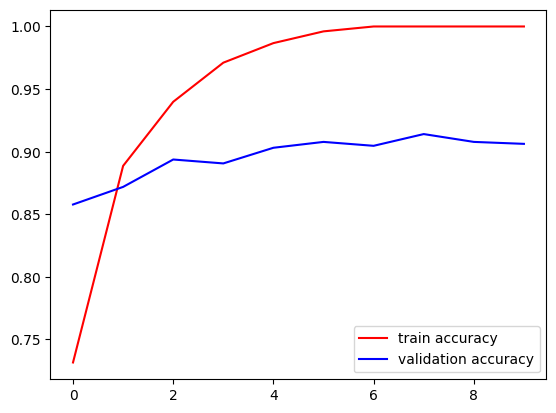

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train accuracy')
plt.plot(history.history['val_accuracy'],color='blue',label='validation accuracy')
plt.legend()
plt.show()

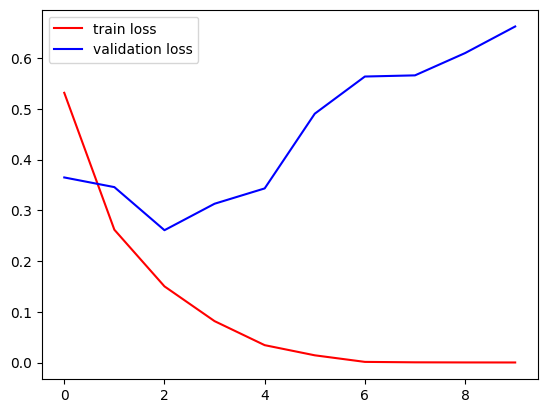

In [15]:
plt.plot(history.history['loss'],color='red',label='train loss')
plt.plot(history.history['val_loss'],color='blue',label='validation loss')
plt.legend()
plt.show()

In [23]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 800 images belonging to 2 classes.


In [24]:
predictions = model.predict(test_data)

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step


In [25]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming the availabilty truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)

# Confusion matrix calculation
cm = confusion_matrix(true_labels, predicted_labels)

# Confusion matrix printing
print("Confusion Matrix:")
print(cm)

# Print the classification report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[372  28]
 [ 37 363]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       400
           1       0.93      0.91      0.92       400

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800



There is overfitting beacuse it performed well on training data but predicts wrong in testing data and hence applying Batchnormalisation and Dropout techniques to handle overfitting

In [26]:
# CNN model creation

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(BatchNormalization())  # To reduce overfitting this is added
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # To reduce overfitting this is added
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # To reduce overfitting this is added
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dropout(0.5))  # To reduce overfitting this is added stronger regularization
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))  # To reduce overfitting this is added
model.add(Dense(1,activation='sigmoid'))  #output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [28]:
history = model.fit(train_data, epochs=10, validation_data=validation_data)

Epoch 1/10
 4/80 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.6074 - loss: 5.1482

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 27s 184ms/step - accuracy: 0.6773 - loss: 6.7056 - val_accuracy: 0.5000 - val_loss: 8.6032
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 0.6973 - loss: 1.8503 - val_accuracy: 0.5000 - val_loss: 10.0353
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - accuracy: 0.6594 - loss: 0.8694 - val_accuracy: 0.5000 - val_loss: 6.2227
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - accuracy: 0.6988 - loss: 0.6732 - val_accuracy: 0.7453 - val_loss: 0.5996
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - accuracy: 0.7254 - loss: 0.5514 - val_accuracy: 0.5828 - val_loss: 4.5454
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - accuracy: 0.7418 - loss: 0.6040 - val_accuracy: 0.6984 - val_loss: 2.8027
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - accuracy: 0.7844 - loss: 0.4430 - val_accuracy: 0.7750 - val_loss: 0.4427
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 128ms/step - accuracy: 0.7914 - loss: 0.4850 - val_accuracy: 0.82

In [29]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 800 images belonging to 2 classes.


In [30]:
predictions = model.predict(test_data)

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step


In [31]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming the availabilty truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)

# Confusion matrix calculation
cm = confusion_matrix(true_labels, predicted_labels)

# Confusion matrix printing
print("Confusion Matrix:")
print(cm)

# Print the classification report
print("\nClassification Report after applying methods to overcome overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[298 102]
 [  8 392]]

Classification Report after applying methods to overcome overfitting:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84       400
           1       0.79      0.98      0.88       400

    accuracy                           0.86       800
   macro avg       0.88      0.86      0.86       800
weighted avg       0.88      0.86      0.86       800



In [32]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from tensorflow.keras.applications.resnet50 import preprocess_input

# ResNet50 preprocessing
resnet_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

resnet_model = Sequential()    #ResNet50 is a pre-trained model
pretrained_model = tf.keras.applications.ResNet50(include_top = False, #because i have my own image of a diff dimension
                                                input_shape = (256,256,3),
                                                pooling = 'max', classes = 2,
                                                weights = 'imagenet')
for layer in pretrained_model.layers:
    layer.trainable = False  #All layers in the Resnet50 is not trainable

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation = 'relu'))
resnet_model.add(Dense(1, activation = 'sigmoid'))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [33]:
from keras.optimizers import Adam
resnet_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

In [34]:
history = resnet_model.fit(train_data, epochs=10, validation_data=validation_data)

Epoch 1/10
 5/80 ━━━━━━━━━━━━━━━━━━━━ 20s 272ms/step - accuracy: 0.5411 - loss: 4.0276

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 32s 230ms/step - accuracy: 0.7328 - loss: 1.0601 - val_accuracy: 0.7984 - val_loss: 0.4244
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.8531 - loss: 0.3316 - val_accuracy: 0.8172 - val_loss: 0.4033
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 159ms/step - accuracy: 0.8813 - loss: 0.2819 - val_accuracy: 0.8687 - val_loss: 0.3102
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 0.8773 - loss: 0.2906 - val_accuracy: 0.7797 - val_loss: 0.5841
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 167ms/step - accuracy: 0.8813 - loss: 0.2849 - val_accuracy: 0.8203 - val_loss: 0.4009
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 202ms/step - accuracy: 0.8875 - loss: 0.2746 - val_accuracy: 0.8609 - val_loss: 0.3155
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 166ms/step - accuracy: 0.9000 - loss: 0.2405 - val_accuracy: 0.8734 - val_loss: 0.3130
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 160ms/step - accuracy: 0.8988 - loss: 0.2432 - val_accuracy: 0.871

In [35]:
predictions = resnet_model.predict(test_data)

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step


In [36]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming the availabilty truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)

# Confusion matrix calculation
cm = confusion_matrix(true_labels, predicted_labels)

# Confusion matrix printing
print("Confusion Matrix:")
print(cm)

# Print the classification report
print("\nClassification Report after applying methods to overcome overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[370  30]
 [ 54 346]]

Classification Report after applying methods to overcome overfitting:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       400
           1       0.92      0.86      0.89       400

    accuracy                           0.90       800
   macro avg       0.90      0.90      0.89       800
weighted avg       0.90      0.90      0.89       800

